## Why Optical Character Recognition (OCR) Models?

In general applications OCR Models are used as models that recognize text optically and outputs the corresponding character set.

This is important in work such as archiving of data and transforming the media of the data displayed from things like written text to digital data.

Here the models will be tested and fitted on the balanced Extended Modified National Institute of Standards and Technology database (EMNIST) and then will be tested on the premade testing split of the dataset.

A confusion matrix will be displayed with the predictions and true labels of the data as well as the cross entropy validation scores of each model.

## The K Nearest Neighbour Model

As the EMNIST Data set is a 1 channel image (Greyscale), we do not need to worry about multiple channels and as such a simple KNN taking each pixel as a feature can be used as the simplest classifier for the data.

In [11]:
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

### Training Data Reading and Map generation

#### Creating mapping for class to char

In [2]:
maps = open("OCR Neural Network/Datasets/emnist-balanced-mapping.txt",'r')
maps = {int(i):chr(int(j)) for i,j in [line.split() for line in maps.readlines()]}

#### Train Data Reading

In [3]:
# Load training data Set
with open("OCR Neural Network/Datasets/emnist-balanced-train.csv", "r") as f:
    reader = csv.reader(f)
    data_clump = np.array(list(reader), dtype=np.uint8)

#### Test Data Reading

In [4]:
with open("OCR Neural Network/Datasets/emnist-balanced-test.csv", "r") as f:
    reader = csv.reader(f)
    test_data_clump = np.array(list(reader), dtype=np.uint8)

### Data pre processing

In [5]:
#creating the training set
head_train = data_clump[:,0] 
img_px_train = data_clump[:,1:]

#normalizing the data
trainmean = np.mean(img_px_train)
trainstd = np.std(img_px_train)
img_px_train = (img_px_train - trainmean) / trainstd #784 row data in 2 dimensions of n img by 784 pixels

#creating the test set
head_test = test_data_clump[:,0] 
img_px_test = test_data_clump[:,1:]

#normalizing the data
img_px_test = (img_px_test - trainmean) / trainstd

print(img_px_train.shape)
print(img_px_test.shape)

(112800, 784)
(18800, 784)


In [6]:
'''
No need to reshape and use pillow to convert to image.
EMNIST dataset already has rotations embedded in it.
'''
frame_train = pd.DataFrame({'Label' : head_train,  'Image' : img_px_train.tolist()})
frame_test = pd.DataFrame({'Label' : head_test,  'Image' : img_px_test.tolist()})

### Creating a general model for KNNClassifier

Since KNN classifiers are likely to be unable to take in images row by row, we'll feed every image as one row of 784 px

In [7]:
class KNNClassifier:
    def __init__(self, n_neighbors=3):
        super(KNNClassifier,self).__init__()
        self.knn = KNeighborsClassifier(n_neighbors=n_neighbors)

    def predict(self, X_train, y_train, X_test):
        self.knn.fit(X_train, y_train)
        return self.knn.predict(X_test)
    
    def conf_matrix(self, y_test, y_pred):
        conf_mat = confusion_matrix(y_test, y_pred)
        plt.imshow(conf_mat, cmap='hot', interpolation='None')
        plt.colorbar()
        plt.show()

    def test_model(self, X_train, y_train, X_test, y_test):
        y_pred = self.predict(X_train, y_train, X_test)
        self.conf_matrix(y_test, y_pred)
        print(self.cross_val(X_train, y_train))
        print(self.accuracy(y_test, y_pred))
    
    def cross_val(self, X_train, y_train, cv=5):
        return cross_val_score(self.knn, X_train, y_train, cv=cv)
    
    def accuracy(self, y_test, y_pred):
        return np.mean(y_test == y_pred)

KNN with 1 neighbors


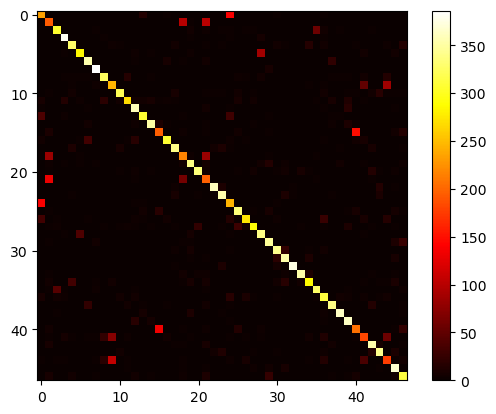

[0.76551418 0.76533688 0.7623227  0.76578014 0.76595745]
0.7687234042553192
KNN with 2 neighbors


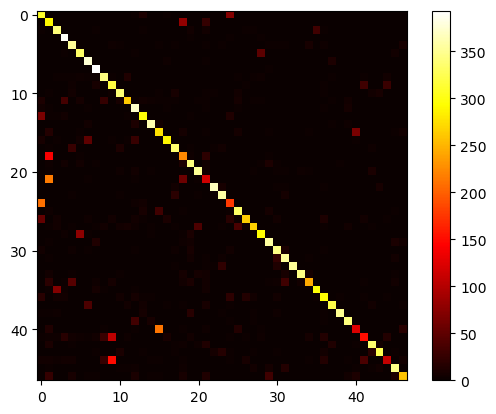

[0.75407801 0.75106383 0.74951241 0.75558511 0.75416667]
0.7606382978723404
KNN with 3 neighbors


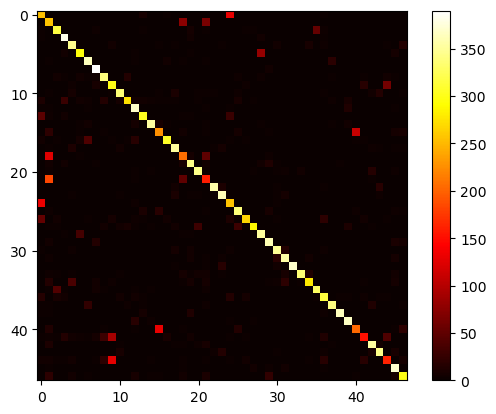

[0.77189716 0.77291667 0.77238475 0.77477837 0.77140957]
0.7801595744680851
KNN with 4 neighbors


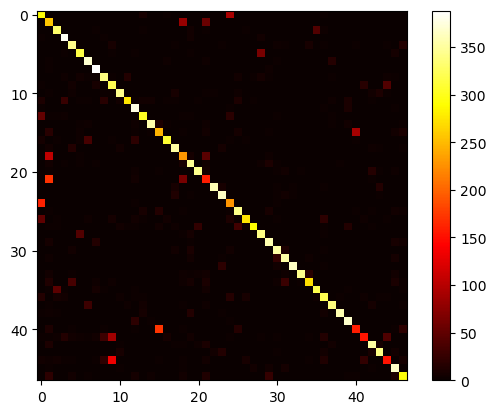

[0.77566489 0.77491135 0.77300532 0.77402482 0.77318262]
0.7831382978723405
KNN with 5 neighbors


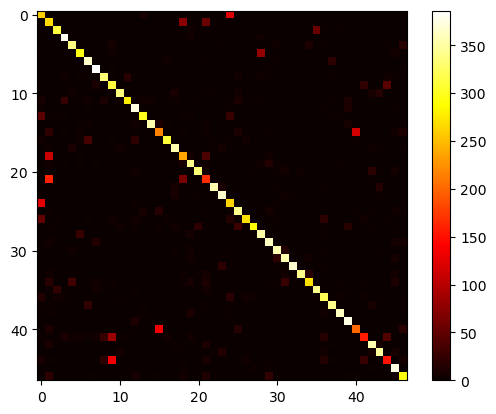

[0.77783688 0.77992021 0.77641844 0.77974291 0.77575355]
0.7846276595744681
KNN with 6 neighbors


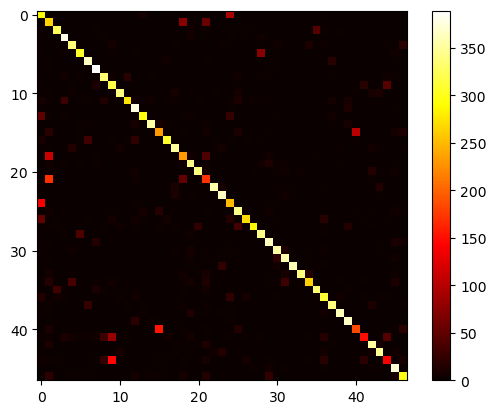

[0.77836879 0.77978723 0.77566489 0.78102837 0.77327128]
0.7827127659574468
KNN with 7 neighbors


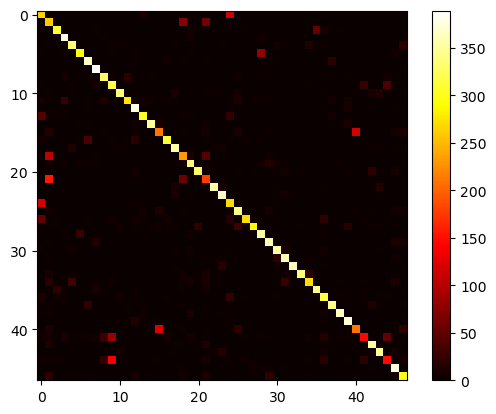

[0.77863475 0.77859043 0.77566489 0.78067376 0.77650709]
0.7839893617021276
KNN with 8 neighbors


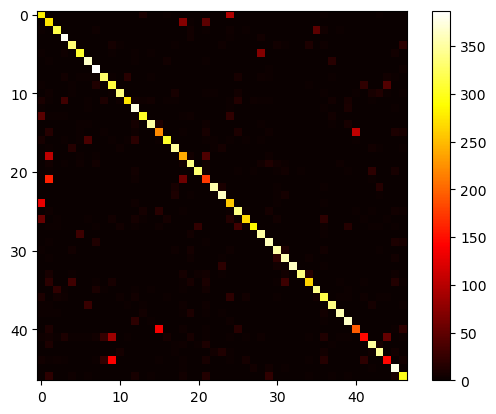

[0.7777039  0.77894504 0.7758422  0.77832447 0.77672872]
0.7830851063829787
KNN with 9 neighbors


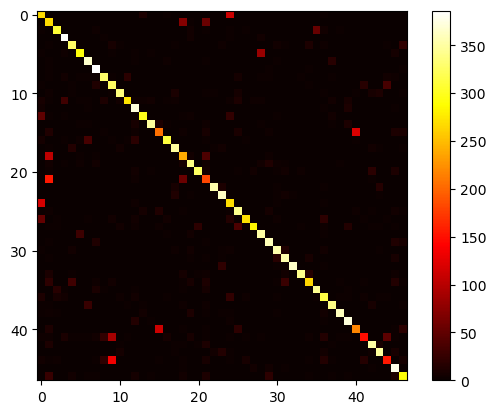

[0.77859043 0.77828014 0.77353723 0.77792553 0.77451241]
0.7819680851063829


In [9]:
for i in range(1, 10):
    print(f"KNN with {i} neighbors")
    knn = KNNClassifier(n_neighbors=i)
    knn.test_model(img_px_train, head_train, img_px_test, head_test)

In [8]:
Test_classifier = KNNClassifier(n_neighbors=6)
y_pred = Test_classifier.predict(img_px_train, head_train, img_px_test)

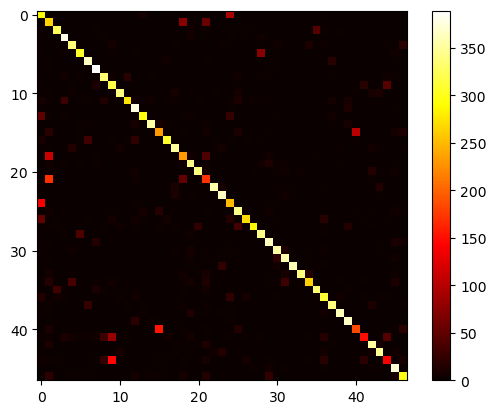

In [9]:
conf_matrix = confusion_matrix(head_test, y_pred)
plt.imshow(conf_matrix, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.show()

In [10]:
score = cross_val_score(Test_classifier.knn, img_px_train, head_train, cv=5)
print(score)

[0.77836879 0.77978723 0.77566489 0.78102837 0.77327128]
